Problem Definition & Key Questions

# Problem Definition

The goal of this project is to explore and analyze the probability distributions of key variables in a real estate dataset. By understanding these distributions, we aim to uncover patterns, variability, and potential probabilistic insights that can inform pricing, investment decisions, and market behavior.

# Key Questions

## Distribution Understanding
- What is the distribution of housing prices?
- Is the price distribution normal, skewed, or heavy-tailed?
- What are the distributions of key features such as:
  - House age
  - Distance to city center / MRT
  - Number of nearby amenities (e.g., convenience stores)

## Statistical Properties
- What are the mean, median, variance, and standard deviation of each variable?
- Are there significant outliers in price or other features?
- How does skewness and kurtosis differ across variables?

## Conditional Distributions
- How does the distribution of housing prices change based on:
  - Location (distance to MRT)
  - Number of nearby stores
  - Age of the house
- Are there noticeable shifts in distribution under different conditions?

## Relationships Between Variables
- How does price vary with distance to MRT?
- Do certain variables exhibit joint distributions or correlations?
- Can we approximate relationships using probabilistic reasoning?

## Probability-Based Insights
- What is the probability that a house costs above a certain threshold?
- What is the probability of finding a house within a specific price range?
- Can we model price using a known distribution (e.g., normal, log-normal)?

## Real-World Interpretation
- What do the distributions tell us about the real estate market?
- Are there segments (e.g., luxury vs affordable) visible in the data?
- How can these probabilistic insights be used for decision-making?

Data Loading & Overview

## 2. Data Loading & Overview

In this section, we load the dataset into Python using pandas and perform an initial inspection.  
The goal is to understand the structure of the data, identify variable types, detect missing values, and get a first impression of the dataset before deeper analysis.

In [5]:
# Import the library
import pandas as pd
import numpy as np

In [6]:
# Display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [7]:
# Load the dataset
file_path = "DuAnKhoaHocDuLieu6.xls"
df = pd.read_csv(file_path)

In [8]:
# Review the data
df.head()

,price,size,year,view
0,"234,314.14",643.09,2015,No sea view
1,"228,581.53",656.22,2009,No sea view
2,"281,626.34",487.29,2018,Sea view
3,"401,255.61","1,504.75",2015,No sea view
4,"458,674.26","1,275.46",2009,Sea view


In [9]:
# Check the shape
df.shape

(100, 4)

In [10]:
# All the columns
df.columns

Index(['price', 'size', 'year', 'view'], dtype='object')

In [11]:
# Check the data types
df.dtypes

price    float64
size     float64
year       int64
view      object
dtype: object

In [12]:
# Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   100 non-null    float64
 1   size    100 non-null    float64
 2   year    100 non-null    int64  
 3   view    100 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ KB


In [13]:
# Describe
df.describe()

,price,size,year
count,100.00,100.00,100.00
mean,"292,289.47",853.02,"2,012.60"
std,"77,051.73",297.94,4.73
min,"154,282.13",479.75,"2,006.00"
25%,"234,280.15",643.33,"2,009.00"
50%,"280,590.72",696.40,"2,015.00"
75%,"335,723.70","1,029.32","2,018.00"
max,"500,681.13","1,842.51","2,018.00"


In [14]:
# Check for missing values
df.isnull().sum()

price    0
size     0
year     0
view     0
dtype: int64

In [15]:
# Check for duplicates
df.duplicated().sum()

0

In [16]:
# Random sample
df.sample(5, random_state=42)

,price,size,year,view
83,"282,683.54",643.09,2018,Sea view
53,"269,523.06",727.88,2006,Sea view
70,"276,875.63","1,021.95",2009,No sea view
45,"300,061.48",698.29,2015,Sea view
44,"293,044.50","1,060.36",2018,No sea view


In [17]:
# Numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
Index(['price', 'size', 'year'], dtype='object')

Categorical columns:
Index(['view'], dtype='object')


In [18]:
# Summary
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"There are {len(numerical_cols)} numerical columns and {len(categorical_cols)} categorical columns.")

The dataset has 100 rows and 4 columns.
There are 3 numerical columns and 1 categorical columns.


Data Cleaning & Preprocessing

### Data Cleaning & Preprocessing

The dataset required minimal preprocessing due to its clean structure:
- No missing values were present.
- Duplicate rows were checked and removed.
- The categorical variable (`view`) was converted into a category type.

The dataset is now ready for exploratory data analysis and distribution modeling.

In [21]:
# Check the duplicates
df.duplicated().sum()

0

In [22]:
# Remove if any
df = df.drop_duplicates()

In [23]:
# Inspect a column
df["view"].value_counts()

view
No sea view    51
Sea view       49
Name: count, dtype: int64

In [24]:
# Convert to categorical
df["view"] = df["view"].astype("category")

In [25]:
# Final types
df.dtypes

price     float64
size      float64
year        int64
view     category
dtype: object

In [26]:
# Rename column
df.columns = df.columns.str.lower()

In [27]:
# Preview
df.head()

,price,size,year,view
0,"234,314.14",643.09,2015,No sea view
1,"228,581.53",656.22,2009,No sea view
2,"281,626.34",487.29,2018,Sea view
3,"401,255.61","1,504.75",2015,No sea view
4,"458,674.26","1,275.46",2009,Sea view


Exploratory Data Analysis (EDA)

### Exploratory Data Analysis Insights

- The distributions of numerical variables show varying shapes, including potential skewness.
- Price appears to vary significantly, suggesting a wide spread and possible outliers.
- Boxplots reveal whether extreme values are present.
- Relationships between variables (e.g., size vs price) indicate possible correlations.
- The categorical variable (`view`) shows how properties are distributed across different categories.

These observations will guide the formal distribution analysis in the next section.

In [30]:
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# Plot style
sns.set(style="whitegrid")

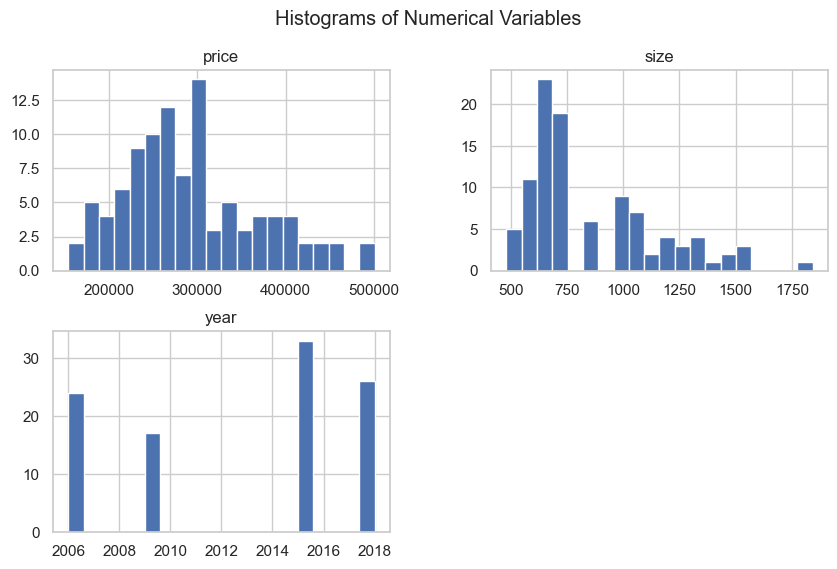

In [32]:
# Histogram for numerical values
df.hist(bins=20, figsize=(10, 6))
plt.suptitle("Histograms of Numerical Variables")
plt.show()

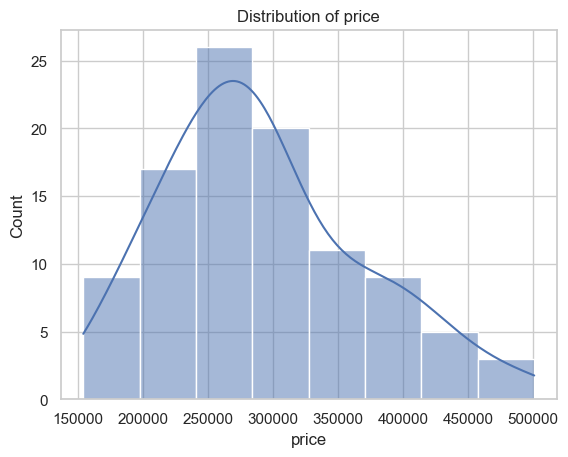

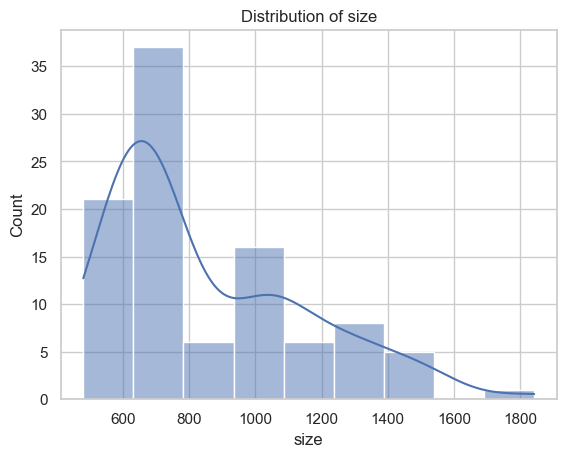

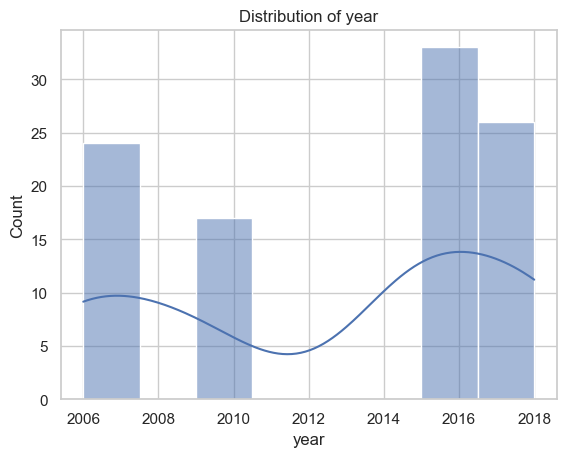

In [33]:
# Individual distribution plots
for col in ["price", "size", "year"]:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

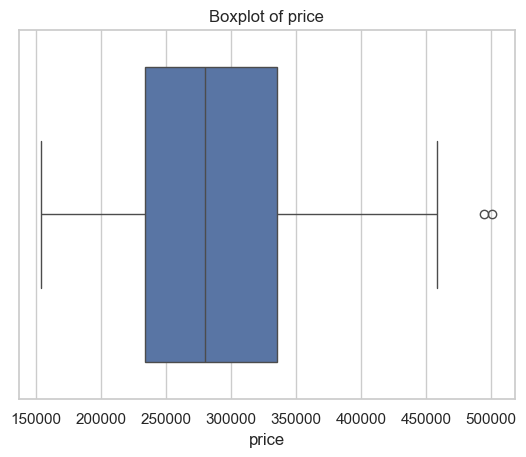

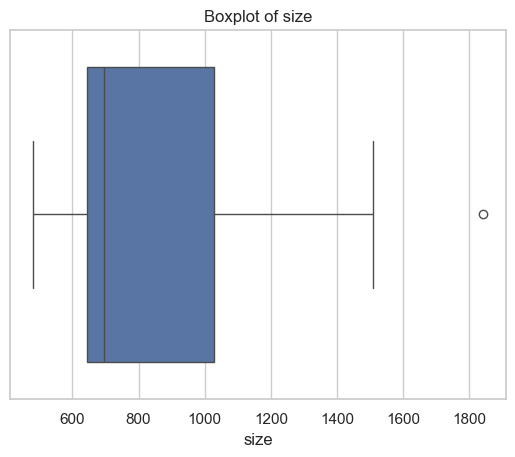

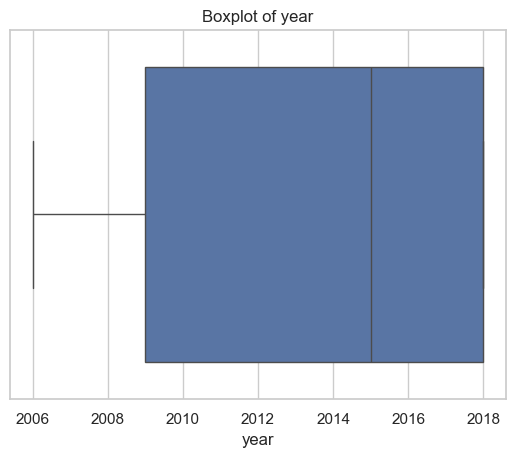

In [34]:
# Detect outliers
for col in ["price", "size", "year"]:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

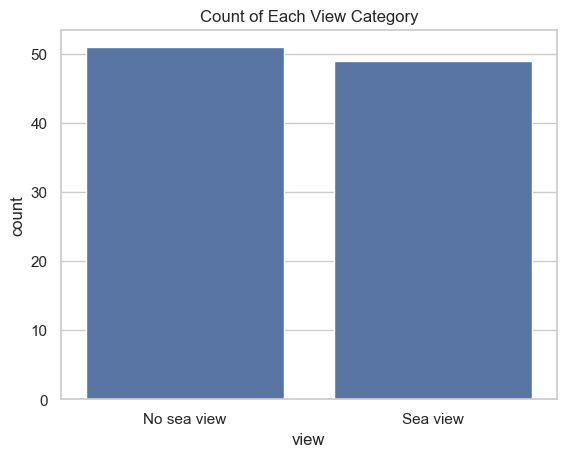

In [35]:
# Plot for categorical values
sns.countplot(x="view", data=df)
plt.title("Count of Each View Category")
plt.show()

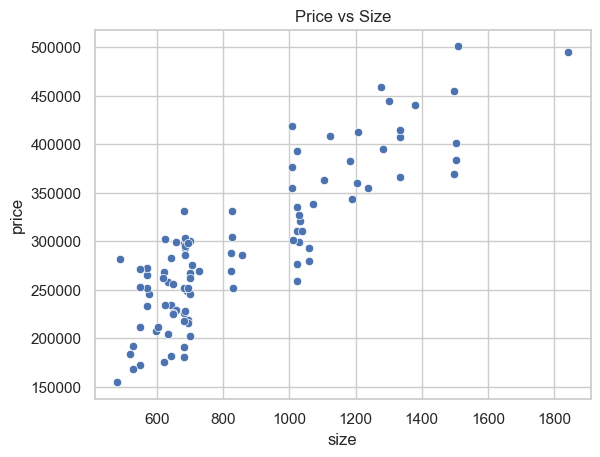

In [36]:
# Price and size
sns.scatterplot(x="size", y="price", data=df)
plt.title("Price vs Size")
plt.show()

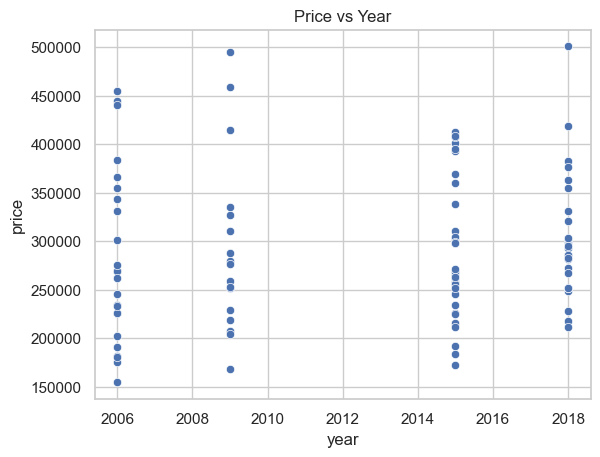

In [37]:
# Price and year
sns.scatterplot(x="year", y="price", data=df)
plt.title("Price vs Year")
plt.show()

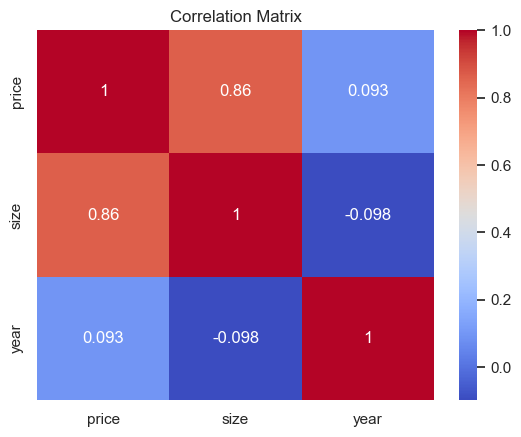

In [38]:
# Correlation matrix
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Distribution Analysis (Core Section)

### Distribution Analysis Insights

- The price variable shows signs of skewness, suggesting it may not follow a normal distribution.
- Log transformation improves symmetry, indicating that price may follow a log-normal distribution.
- Skewness and kurtosis values confirm the presence of asymmetry and potential outliers.
- The comparison with a normal distribution shows deviations, especially in the tails.
- Empirical probability calculations provide insights into real-world likelihoods (e.g., price ranges).

Overall, the dataset demonstrates that real estate prices are better modeled using non-normal distributions, which aligns with real-world economic behavior.

In [41]:
# Import statistics tools
from scipy.stats import skew, kurtosis

In [42]:
# Compute skew
for col in ["price", "size", "year"]:
    print(f"{col.upper()}")
    print(f"Skewness: {skew(df[col]):.2f}")
    print(f"Kurtosis: {kurtosis(df[col]):.2f}")
    print("-" * 30)

PRICE
Skewness: 0.62
Kurtosis: -0.11
------------------------------
SIZE
Skewness: 1.03
Kurtosis: 0.23
------------------------------
YEAR
Skewness: -0.30
Kurtosis: -1.54
------------------------------


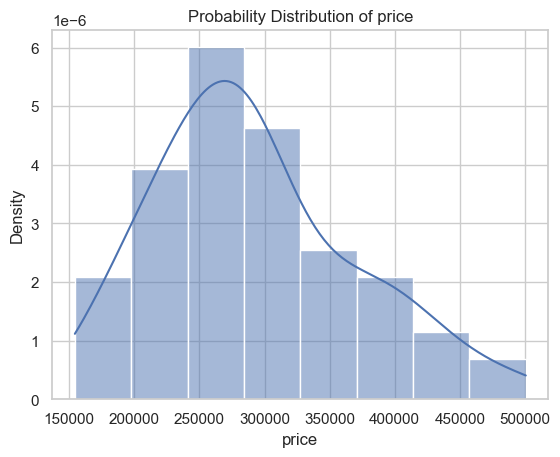

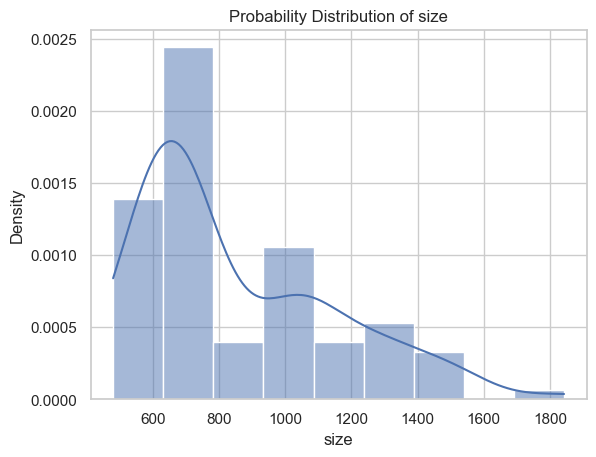

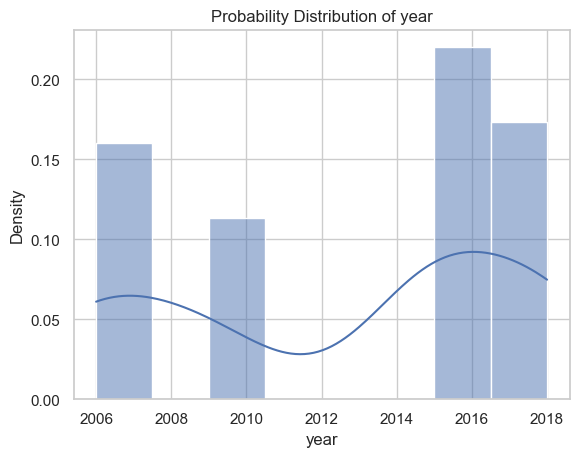

In [43]:
# Distribution
for col in ["price", "size", "year"]:
    plt.figure()
    sns.histplot(df[col], kde=True, stat="density")
    plt.title(f"Probability Distribution of {col}")
    plt.ylabel("Density")
    plt.show()

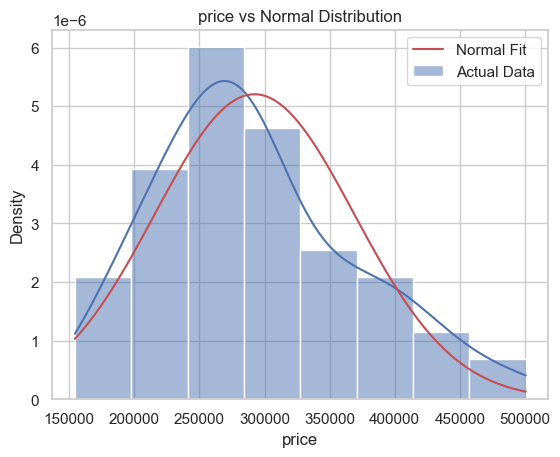

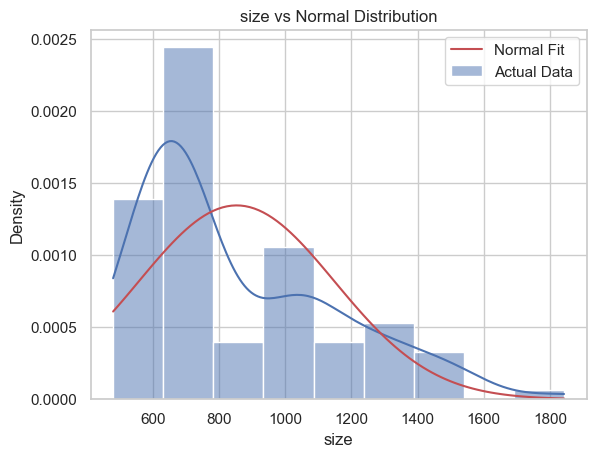

In [44]:
# Normal distribution comparison
from scipy.stats import norm

for col in ["price", "size"]:
    plt.figure()
    
    sns.histplot(df[col], kde=True, stat="density", label="Actual Data")
    
    mu, std = norm.fit(df[col])
    x = np.linspace(df[col].min(), df[col].max(), 100)
    p = norm.pdf(x, mu, std)
    
    plt.plot(x, p, 'r', label="Normal Fit")
    plt.title(f"{col} vs Normal Distribution")
    plt.legend()
    plt.show()

In [45]:
# Probability calculation
threshold = df["price"].mean()

prob = (df["price"] > threshold).mean()

print(f"Probability that price is above mean: {prob:.2f}")

Probability that price is above mean: 0.45


In [46]:
# Probability within a range
lower = df["price"].quantile(0.25)
upper = df["price"].quantile(0.75)

prob_range = ((df["price"] >= lower) & (df["price"] <= upper)).mean()

print(f"Probability price is within IQR: {prob_range:.2f}")

Probability price is within IQR: 0.50


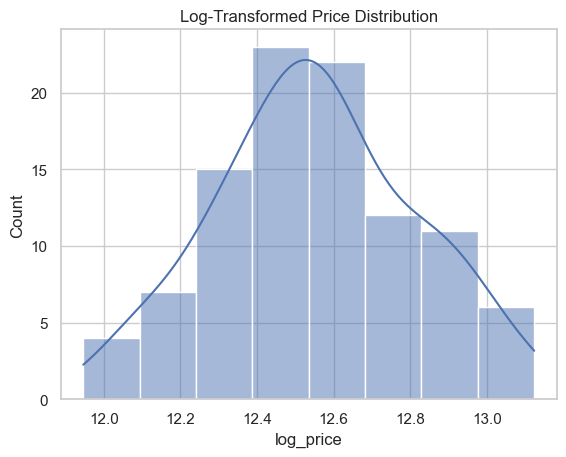

In [47]:
# Tranformation
df["log_price"] = np.log(df["price"])

sns.histplot(df["log_price"], kde=True)
plt.title("Log-Transformed Price Distribution")
plt.show()

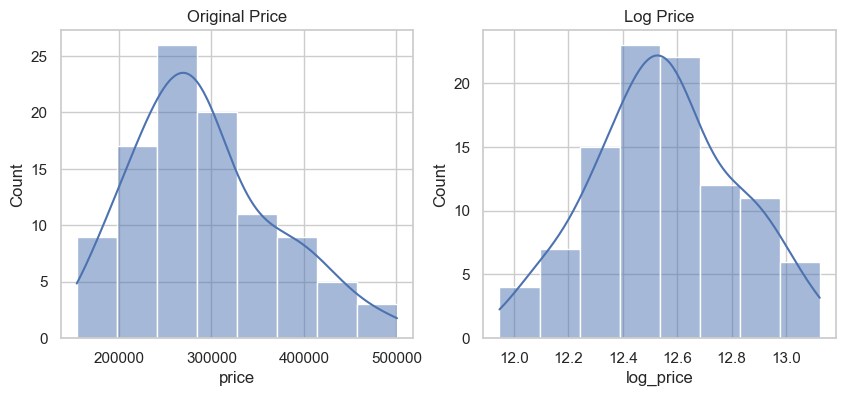

In [48]:
# Original and transformed
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df["price"], kde=True)
plt.title("Original Price")

plt.subplot(1,2,2)
sns.histplot(df["log_price"], kde=True)
plt.title("Log Price")

plt.show()

Statistical Measures & Moments

### Statistical Measures & Moments Insights

- The mean represents the expected value of each variable.
- Differences between mean and median indicate skewness in the data.
- Variance and standard deviation measure the spread and uncertainty of each variable.
- The coefficient of variation allows comparison of variability across different variables.
- Quantiles provide a probability-based interpretation of the data, showing how values are distributed across percentiles.

These statistical measures confirm and support the distribution patterns observed earlier, providing a mathematical foundation for the analysis.

In [51]:
# Basic statistical measurements
df[["price", "size", "year"]].agg(["mean", "median", "var", "std"])

,price,size,year
mean,"292,289.47",853.02,"2,012.60"
median,"280,590.72",696.40,"2,015.00"
var,"5,936,968,714.55","88,769.41",22.36
std,"77,051.73",297.94,4.73


In [52]:
# Interpretation of mean and median
for col in ["price", "size", "year"]:
    mean = df[col].mean()
    median = df[col].median()
    
    print(f"{col.upper()}")
    print(f"Mean: {mean:.2f}, Median: {median:.2f}")
    
    if mean > median:
        print("→ Right-skewed distribution")
    elif mean < median:
        print("→ Left-skewed distribution")
    else:
        print("→ Symmetric distribution")
        
    print("-" * 30)

PRICE
Mean: 292289.47, Median: 280590.72
→ Right-skewed distribution
------------------------------
SIZE
Mean: 853.02, Median: 696.40
→ Right-skewed distribution
------------------------------
YEAR
Mean: 2012.60, Median: 2015.00
→ Left-skewed distribution
------------------------------


In [53]:
# Interpretation of variance and standard deviation
for col in ["price", "size", "year"]:
    var = df[col].var()
    std = df[col].std()
    
    print(f"{col.upper()}")
    print(f"Variance: {var:.2f}")
    print(f"Standard Deviation: {std:.2f}")
    print("-" * 30)

PRICE
Variance: 5936968714.55
Standard Deviation: 77051.73
------------------------------
SIZE
Variance: 88769.41
Standard Deviation: 297.94
------------------------------
YEAR
Variance: 22.36
Standard Deviation: 4.73
------------------------------


In [54]:
# Coefficient
for col in ["price", "size", "year"]:
    cv = df[col].std() / df[col].mean()
    
    print(f"{col.upper()}")
    print(f"Coefficient of Variation: {cv:.2f}")
    print("-" * 30)

PRICE
Coefficient of Variation: 0.26
------------------------------
SIZE
Coefficient of Variation: 0.35
------------------------------
YEAR
Coefficient of Variation: 0.00
------------------------------


In [55]:
# Quantiles
df[["price", "size", "year"]].quantile([0.25, 0.5, 0.75, 0.9])

,price,size,year
0.25,"234,280.15",643.33,"2,009.00"
0.50,"280,590.72",696.40,"2,015.00"
0.75,"335,723.70","1,029.32","2,018.00"
0.90,"407,030.86","1,304.27","2,018.00"


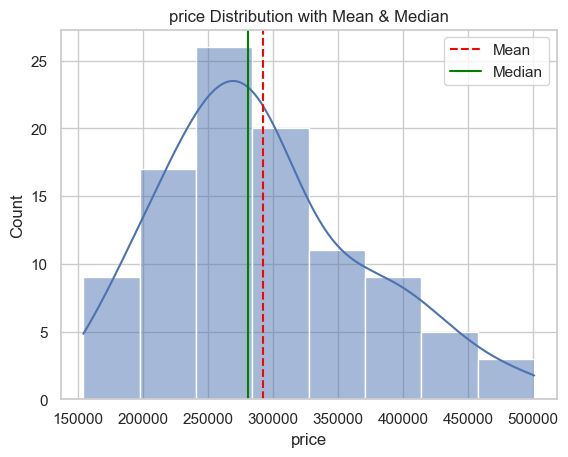

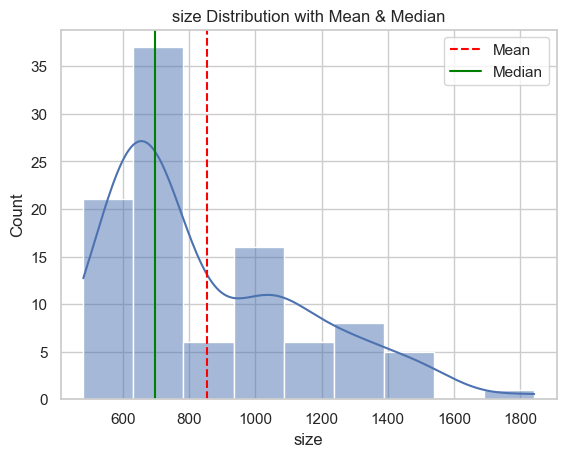

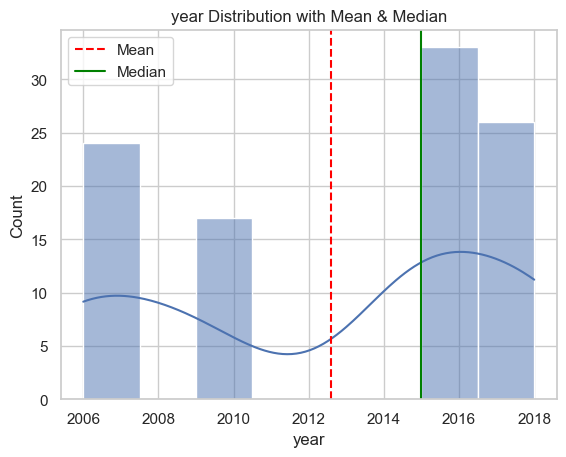

In [56]:
# Distribution visualization
for col in ["price", "size", "year"]:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    plt.axvline(df[col].median(), color='green', linestyle='-', label='Median')
    plt.title(f"{col} Distribution with Mean & Median")
    plt.legend()
    plt.show()

Conditional & Comparative Distributions

### Conditional & Comparative Distribution Insights

- The distribution of price varies across different view categories.
- Certain views show higher average prices, indicating a conditional relationship.
- Variability differs by category, suggesting different levels of uncertainty.
- Conditional probabilities (e.g., P(price > mean | view)) highlight how likelihood changes based on features.
- Differences in size distributions across views may explain price variation.

These findings demonstrate that price is not independent of other variables and is influenced by property characteristics, reinforcing the importance of conditional distributions in real-world data.

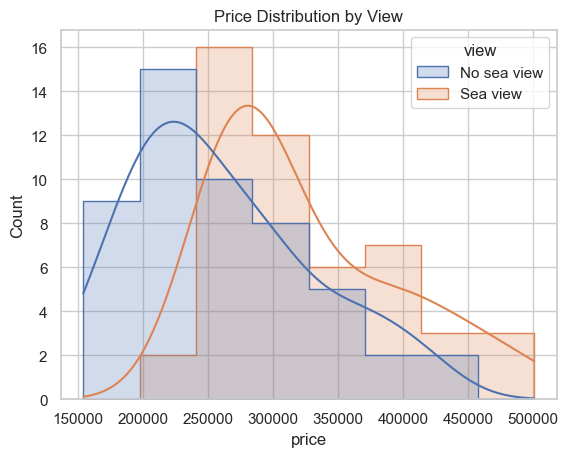

In [59]:
# Distribution by category
sns.histplot(data=df, x="price", hue="view", kde=True, element="step")
plt.title("Price Distribution by View")
plt.show()

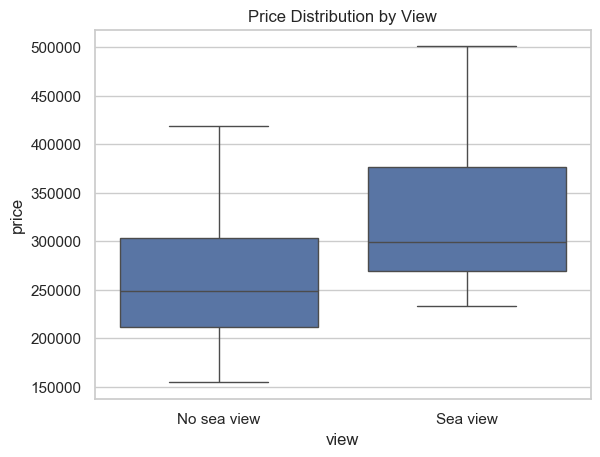

In [60]:
# Comparison
sns.boxplot(x="view", y="price", data=df)
plt.title("Price Distribution by View")
plt.show()

In [61]:
# Summary by category
df.groupby("view")["price"].agg(["mean", "median", "std", "count"])

/var/folders/xz/1ks3m7992j3f8vd9kxhcld300000gn/T/ipykernel_1538/1258256521.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("view")["price"].agg(["mean", "median", "std", "count"])


,mean,median,std,count
view,,,,
No sea view,"261,186.23","248,337.60","69,064.59",51
Sea view,"324,662.23","298,926.50","71,962.70",49


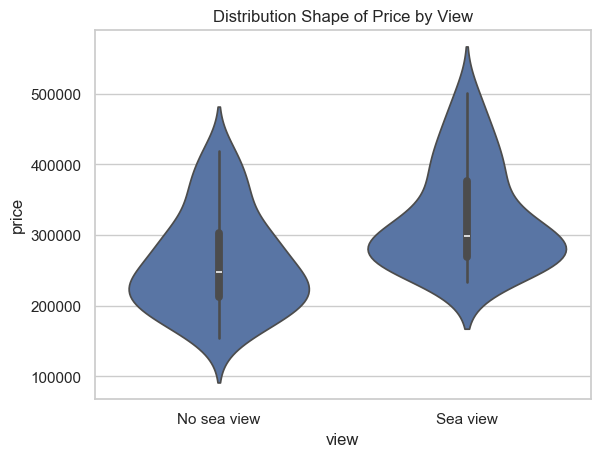

In [62]:
# Violin plot
sns.violinplot(x="view", y="price", data=df)
plt.title("Distribution Shape of Price by View")
plt.show()

In [63]:
# Conditional probability example
overall_mean = df["price"].mean()

for v in df["view"].unique():
    subset = df[df["view"] == v]
    prob = (subset["price"] > overall_mean).mean()
    
    print(f"P(price > mean | view = {v}) = {prob:.2f}")

P(price > mean | view = No sea view) = 0.31
P(price > mean | view = Sea view) = 0.59


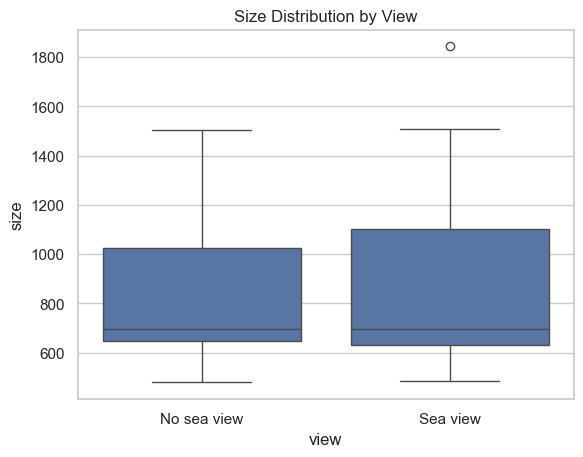

In [64]:
# Compare distribution of size by view
sns.boxplot(x="view", y="size", data=df)
plt.title("Size Distribution by View")
plt.show()

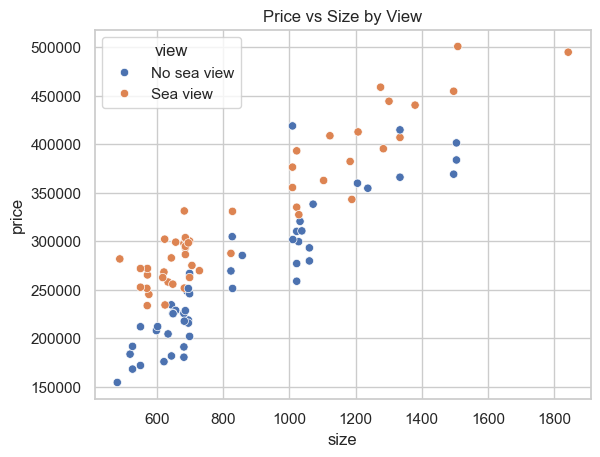

In [65]:
# Plot by category
sns.scatterplot(x="size", y="price", hue="view", data=df)
plt.title("Price vs Size by View")
plt.show()

Probability Modeling

### Probability Modeling Insights

- The normal distribution provides a baseline model but does not fully capture the shape of the price distribution.
- The log-normal distribution better fits the data, especially for skewed variables like price.
- Comparing empirical and theoretical probabilities reveals differences between real-world data and idealized models.
- This highlights the importance of selecting appropriate probability distributions when modeling real-world phenomena.

Overall, real estate prices are better modeled using log-normal distributions, reflecting their asymmetric nature and economic behavior.

In [68]:
# Distribution tools
from scipy.stats import norm, lognorm

In [69]:
# Fit normal distribution
mu, std = norm.fit(df["price"])

print(f"Mean (mu): {mu:.2f}")
print(f"Std Dev (sigma): {std:.2f}")

Mean (mu): 292289.47
Std Dev (sigma): 76665.50


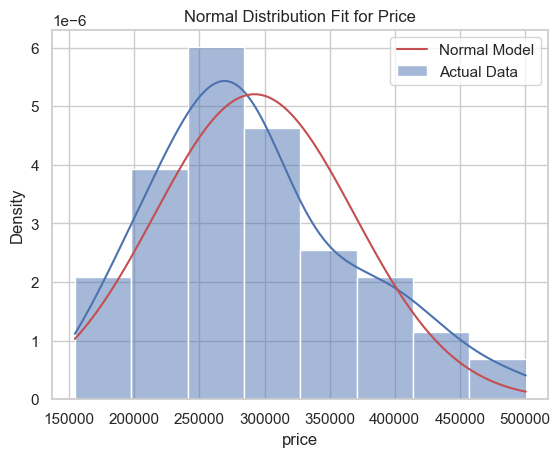

In [70]:
# Visualize normal and actual data
x = np.linspace(df["price"].min(), df["price"].max(), 100)

plt.figure()
sns.histplot(df["price"], kde=True, stat="density", label="Actual Data")

pdf = norm.pdf(x, mu, std)
plt.plot(x, pdf, 'r', label="Normal Model")

plt.title("Normal Distribution Fit for Price")
plt.legend()
plt.show()

In [71]:
# Fit distribution
shape, loc, scale = lognorm.fit(df["price"], floc=0)

print(f"Shape: {shape:.2f}, Scale: {scale:.2f}")

Shape: 0.26, Scale: 282636.46


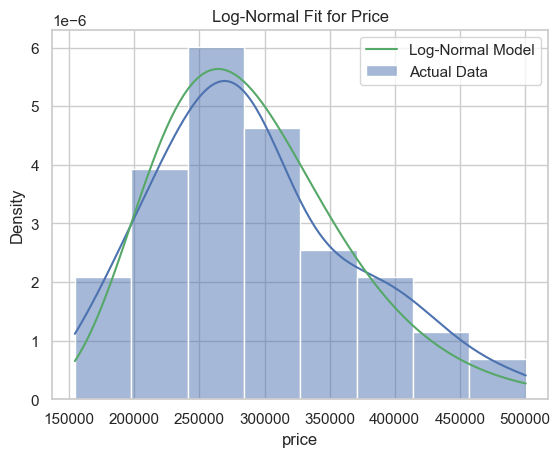

In [72]:
# Compare
x = np.linspace(df["price"].min(), df["price"].max(), 100)

plt.figure()
sns.histplot(df["price"], kde=True, stat="density", label="Actual Data")

pdf_lognorm = lognorm.pdf(x, shape, loc, scale)
plt.plot(x, pdf_lognorm, 'g', label="Log-Normal Model")

plt.title("Log-Normal Fit for Price")
plt.legend()
plt.show()

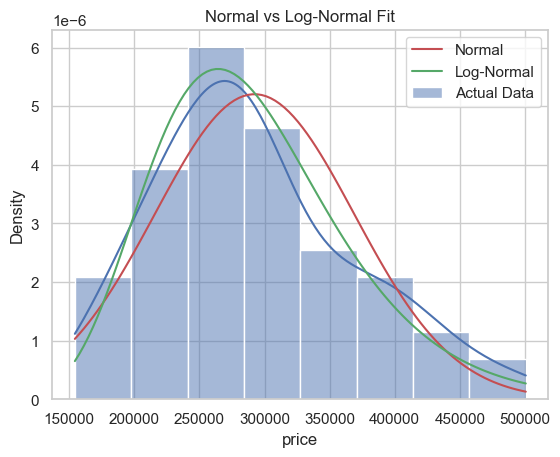

In [73]:
# Compare both model
plt.figure()

sns.histplot(df["price"], kde=True, stat="density", label="Actual Data")

pdf_norm = norm.pdf(x, mu, std)
pdf_lognorm = lognorm.pdf(x, shape, loc, scale)

plt.plot(x, pdf_norm, 'r', label="Normal")
plt.plot(x, pdf_lognorm, 'g', label="Log-Normal")

plt.title("Normal vs Log-Normal Fit")
plt.legend()
plt.show()

In [74]:
# Theoretical probability
threshold = df["price"].mean()

prob_model = 1 - norm.cdf(threshold, mu, std)

print(f"Theoretical P(price > mean): {prob_model:.2f}")

Theoretical P(price > mean): 0.50


In [75]:
# Compare emperical and theoretical
prob_empirical = (df["price"] > threshold).mean()

prob_theoretical = 1 - norm.cdf(threshold, mu, std)

print(f"Empirical: {prob_empirical:.2f}")
print(f"Theoretical (Normal): {prob_theoretical:.2f}")

Empirical: 0.45
Theoretical (Normal): 0.50


Insights & Interpretation

# 9. Insights & Interpretation

## Distribution Behavior

- The distribution of housing prices is positively skewed, indicating that most properties are clustered in the lower to mid-price range, with a smaller number of high-priced properties.
- This skewness suggests that the price variable does not follow a normal distribution and is better represented by a log-normal distribution.
- The presence of heavier tails indicates occasional high-value properties, which increase variability.

## Variability & Uncertainty

- The variance and standard deviation of price are relatively high, reflecting significant spread in property values.
- The coefficient of variation shows that price is more variable relative to its mean compared to other variables.
- This implies higher uncertainty when predicting property prices.

## Conditional Relationships

- The distribution of price changes noticeably across different `view` categories.
- Certain views are associated with higher average prices and different levels of variability.
- This demonstrates that price is conditionally dependent on property characteristics.

## Probability Insights

- Empirical probability calculations show the likelihood of properties falling within certain price ranges.
- The probability of a house being above the mean price varies depending on the `view`, highlighting conditional probability effects.
- Quantiles provide a clear probabilistic interpretation of the dataset (e.g., top 25% of prices).

## Model Fit & Real-World Behavior

- The normal distribution provides a rough approximation but fails to capture skewness.
- The log-normal model aligns more closely with the observed data.
- Differences between empirical and theoretical probabilities highlight the limitations of simple models.

## Real-World Implications

- Real estate markets are inherently skewed, with a concentration of moderately priced homes and a few expensive outliers.
- Property features such as view and size significantly influence price distributions.
- Understanding distributions allows for better decision-making in pricing, investment, and risk assessment.

In [78]:
# Print summary
summary = df[["price", "size", "year"]].agg(["mean", "std", "min", "max"])
summary

,price,size,year
mean,"292,289.47",853.02,"2,012.60"
std,"77,051.73",297.94,4.73
min,"154,282.13",479.75,"2,006.00"
max,"500,681.13","1,842.51","2,018.00"


Conclusion

# 10. Conclusion

This project explored the application of probability concepts, particularly distributions, within a real estate dataset. Through exploratory data analysis and statistical modeling, key patterns in housing prices and related variables were identified.

The analysis revealed that housing prices exhibit a positively skewed distribution, indicating that most properties fall within a moderate price range, while a smaller number of high-value properties create a long tail. This behavior aligns with real-world economic patterns and supports the use of log-normal distributions for modeling price.

Statistical measures such as mean, variance, and standard deviation provided insight into the central tendency and variability of the data, while skewness and kurtosis helped characterize the shape of the distributions. Conditional analysis further demonstrated that property features, such as view, influence the distribution of prices, highlighting the importance of conditional probability in understanding real-world data.

Additionally, comparing empirical probabilities with theoretical models emphasized the gap between idealized assumptions and observed data, reinforcing the need for appropriate model selection.

Overall, this project demonstrates how probability distributions can be used to analyze, interpret, and model real-world datasets. These techniques are essential in data science for making informed decisions, understanding uncertainty, and uncovering meaningful patterns in complex data.